In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


1. Reading the CSV files

In [2]:
train = pd.read_csv("../input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../input/competitions/house-prices-advanced-regression-techniques/test.csv")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (1460, 81), Test shape: (1459, 80)


2. Data Cleaning & Feature Selection

In [3]:
y = np.log1p(train['SalePrice'])

X_raw = train.drop(['Id', 'SalePrice'], axis=1)
X_test_raw = test.drop(['Id'], axis=1)

combined = pd.concat([X_raw, X_test_raw], axis=0)

#handling missing values
for col in combined.columns:
    if combined[col].dtype in [np.number]:
        combined[col] = combined[col].fillna(combined[col].median())
    else:
        combined[col] = combined[col].fillna('None')
combined_encoded = pd.get_dummies(combined, drop_first=True)

X_all = combined_encoded.iloc[:len(train)]
X_test_all = combined_encoded.iloc[len(train):]

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)
print(f"New X_train features: {X_train.shape[1]}")

New X_train features: 267


/tmp/ipykernel_16/523944987.py:10: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if combined[col].dtype in [np.number]:


3. Searching for optimal regularization parameter

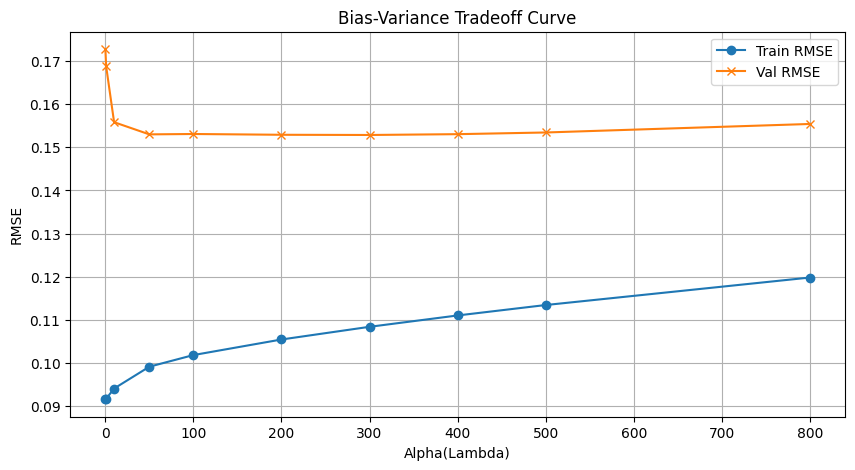

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

alphas = [0.1, 1, 10, 50, 100, 200, 300, 400, 500, 800]
train_scores = []
val_scores = []
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    t_rmse = root_mean_squared_error(y_train, model.predict(X_train_scaled))
    v_rmse = root_mean_squared_error(y_val, model.predict(X_val_scaled))
    train_scores.append(t_rmse)
    val_scores.append(v_rmse)
    
plt.figure(figsize=(10,5))
plt.plot(alphas, train_scores, label='Train RMSE', marker='o')
plt.plot(alphas, val_scores, label='Val RMSE', marker='x')
plt.xlabel('Alpha(Lambda)')
plt.ylabel('RMSE')
plt.title('Bias-Variance Tradeoff Curve')
plt.grid(True)
plt.legend()
plt.show()

4. Final Regularized Linear Regression Model

In [5]:
final = Ridge(alpha=200.0)
final.fit(X_train_scaled, y_train)

y_train_pred = final.predict(X_train_scaled)
y_val_pred = final.predict(X_val_scaled)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
val_rmse = root_mean_squared_error(y_val, y_val_pred)

print(f"Training RMSE: {train_rmse}, Val RMSE: {val_rmse}")

X_test_scaled = scaler.transform(X_test_all)
y_test_pred = final.predict(X_test_scaled)
y_test_res = np.expm1(y_test_pred)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': y_test_res
})

submission.to_csv('submission.csv', index=False)
print("Submission file successfully created")

Training RMSE: 0.10546940382776165, Val RMSE: 0.15289574041244092
Submission file successfully created
